In [1]:
from functions.clustering_functions import clustering_2_communities, ARI_fscore
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
from functions.plots import plot_ARI_f1
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic_fit_matrix, ask_yes_no, ask_input
from functions.cosmograph_functions import visualize_graph_paysim

In [2]:
user_input = ask_yes_no("\nDo you want to load data?")

name = 'PAYSIM'
if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)
    
else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)
    
results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save, times_dict = run_squic_fit_matrix(Y_norm, knn_matrix, results_squic, name, dimension)
    
else:
    results_squic, squic_method, save, times_dict = run_squic_fit(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
          0         1         2         3         4         5         6  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.006122  0.006122  0.006122  0.006122  0.006122  0.006122  0.006122   
2  0.000026  0.000026  0.057122  0.057122  0.057122  0.057122  0.057122   
3  0.000020  0.000020  0.000020  0.000020  0.000020  0.000020  0.000020   
4  0.000053  0.000053  0.000053  0.000053  0.000053  0.000053  0.000053   

          7         8         9  ...       355       356       357       358  \
0  0.002564  0.015047  0.015047  ...  3.166267  3.222139  3.255435  3.266949   
1  0.006122  0.079411  0.102893  ...  2.911986  2.739778  2.739778  2.739778   
2  0.057122  0.101109  0.125164  ...  2.052844  2.038521  2.038521  2.028413   
3  0.000020  0.000020  0.040211  ...  3.392320  3.317149  3.333798  0.000000   
4  0.353670  0.353670  0.353670  ...  4.623844  5.055990  5.055990  5.055990   

        359       360       361       362       3

In [3]:
from functions.cosmograph_functions import cosmograph_from_theta
widget_dict = {}
for rho, model_fit in results_squic[squic_method].items():
    widget_dict = cosmograph_from_theta(model_fit, rho, widget_dict)

In [4]:
widget_dict

{0.9: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.85: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.8: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_color='#E3E3E3', link_greyout_opacity=0.1, link_source_by='source', link_target_by='target', link_width_by='weight', point_color='#0d5da4', point_size_by='degree', random_seed=None),
 0.75: Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_c

In [5]:
# widget_dict[0.6]


for rho 0.9 graph is connected: False
Computing spectral clustering for rho 0.9...
For rho 0.9 takes 0.09 seconds

for rho 0.85 graph is connected: False
Computing spectral clustering for rho 0.85...
For rho 0.85 takes 0.02 seconds

for rho 0.8 graph is connected: False
Computing spectral clustering for rho 0.8...
For rho 0.8 takes 0.02 seconds

for rho 0.75 graph is connected: False
Computing spectral clustering for rho 0.75...
For rho 0.75 takes 0.02 seconds

for rho 0.7 graph is connected: False
Computing spectral clustering for rho 0.7...
Attempt 1 failed: ARPACK error -1: No convergence (1001 iterations, 0/3 eigenvectors converged)
For rho 0.7 takes 0.77 seconds
for lambda = 0.9 : {'Spectral': {'nCluster': 2, 'ARI': 0.0, 'f1': 0.41}}
for lambda = 0.85 : {'Spectral': {'nCluster': 2, 'ARI': 0.12, 'f1': 0.69}}
for lambda = 0.8 : {'Spectral': {'nCluster': 2, 'ARI': 0.31, 'f1': 0.79}}
for lambda = 0.75 : {'Spectral': {'nCluster': 2, 'ARI': 0.63, 'f1': 0.9}}
for lambda = 0.7 : {'Spectr

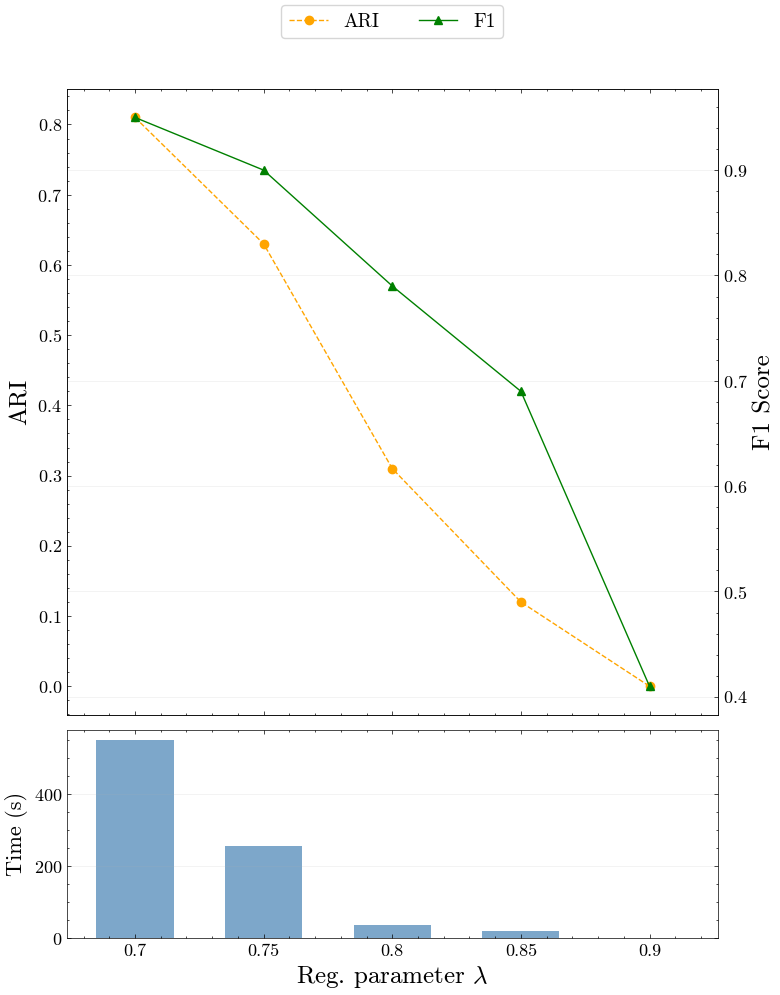

In [6]:
# Results
dict_cluster = clustering_2_communities(results_squic, squic_method, dimension)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for lambda = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, times_dict, save)

In [89]:
graph = visualize_graph_paysim(results_squic, squic_method, dict_cluster, account_prop)


0.6
0.5
0.4
0.3
0.2
0.1


In [90]:
# graph[0.3]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…